In [1]:
import random 
import math
import matplotlib.pyplot as plt
import numpy as np
import json
from scipy.optimize import curve_fit

In [2]:
# Carregar a rede 


#Função que gera a rede de orientações aleatórias

def rede(N):
    lista = []
    for i in range(int(N)):
        pi = np.pi
        teta = np.random.uniform(0,pi)
        phi = np.random.uniform(0,(2*pi))

        x = np.sin(teta)*np.cos(phi)
        y = np.sin(teta)*np.sin(phi)
        z = np.cos(teta)
        lista.append([round(x,5),round(y,5),round(z,5)])
    return lista

#Parâmetro 

N_rede = 100   #(tamanho da rede)

#Arquivo 

d = rede(N_rede)

with open("dados_4.txt", "w") as arquivo:
    json.dump(d, arquivo)
arquivo.close()



In [ ]:
#Funções

with open("dados_4.txt", "r") as arquivo:
    d = json.load(arquivo)     # Rede

def calc_dt(k):
    u = random.random()
    return -np.log(u)/sum(k)

def K_to_prob(k):
    K_T = sum(k)
    return [k[i]/K_T for i in range(len(k))]

def which_event(p):
    s = [sum(p[:i+1]) for i in range(len(p))]
    u = random.random()
    if u < s[0]:
        return 0
    if u < s[1]:
        return 1
    if u <= s[2]:
        return 2 

def calc_kappa2(mu_d, mu_a):
    mu_d = np.array(mu_d)
    mu_a = np.array(mu_a)
    kappa = np.dot(mu_d,mu_a) - 3*(mu_d[0])*(mu_a[0])  # Rede na coordenada x
    return kappa**2

def calc_K(kappa2,R_0,r,Tau):
    K = ((R_0/r)**6)*kappa2/Tau
    return K
    
def cond_contorno(N,X_0):
    if X_0 > N:
        return 0
    if X_0 < 0:
        return N
    return X_0


#Função principal

def traj(d,R_0,r,Tau):
    N = len(d)     #Tamanho da rede
    X_0 = random.randint(0,N-1)
    alive = True
    t = 0
    n = 0
    traj = [X_0]
    x = X_0
    contagem = 0

    

    while alive:
        x_E_con = cond_contorno(N-1,X_0 -1)
        x_D_con = cond_contorno(N-1,X_0 +1)
        s_i = d[X_0]
        s_E = d[x_E_con]
        s_D = d[x_D_con]
        kappa2_E = calc_kappa2(s_i,s_E)
        kappa2_D = calc_kappa2(s_i,s_D)
        

        K_Emi = 1/Tau
        K_Es = calc_K(kappa2_E,R_0,r,Tau)
        K_Dir = calc_K(kappa2_D,R_0,r,Tau)

        list_K = [K_Emi, K_Dir, K_Es]

        P = K_to_prob(list_K) 
        dt = calc_dt(list_K)
        t += dt
        event = which_event(P)

        if event ==0:
            alive = False
        if event == 1:    #Pulo para a direita
            X_0 = x_D_con
            x += 1
            contagem +=1
            traj.append(x)
        if event ==2:     #Pulo para a esquerda 
            X_0 = x_E_con
            x -= 1 
            contagem +=1
            traj.append(x)

    return(traj,t,contagem)


# Funções do comprimento de difusão 

def L_D_calc(d,R_0,r,Tau,n):     # para n éxcitons
    s = []
    s_N = []
    for i in range(n):
        t = traj(d,R_0,r,Tau)
        trajetoria = t[0] 
        passos = t[2]

        X_0 = trajetoria[0]
        X_F = trajetoria[-1]
        s.append((X_F - X_0)**2)
        s_N.append(passos)

    N = (sum(s_N)/n)
    L_D_steps = r*(N**0.5)
    L_D_sig = np.sqrt(sum(s)/n)

    return L_D_sig, L_D_steps



def L_D_an(R_0,r):
    L_D = (np.sqrt(2)*((2/3)*R_0)**3)/(r**2)  #para contagem de passos dos dois lados 
    return L_D




In [ ]:
#Parâmetros  

R_0 = 2    # R_F = k^2 * R_0
r = 1      # distância entre as moléculas 
Tau = 100

In [ ]:
# Verificação do número de éxitons necessários 

with open("dados_4.txt", "r") as arquivo:
    d = json.load(arquivo)     # Rede

N = 400   #Número máximo de éxcitons 

from joblib import Parallel, delayed

resultados = Parallel(n_jobs=-1)(delayed(L_D_calc)(d,R_0,r,Tau,n) for n in range(1,N))


lista_L_D_sig = [resultados[i][0] for i in range(N-1)]
lista_L_D_steps  = [resultados[i][1] for i in range(N-1)]
lista_n = [i for i in range(N-1)]



#lista_L_D_sig = []
#lista_L_D_steps = []
#lista_n = []
#for n in range(1,N+1):
#    L_D = L_D_calc(d,R_0,r,Tau,n)
#    lista_L_D_sig.append(L_D[0])
#    lista_L_D_steps.append(L_D[1])
#    lista_n.append(n)

print(lista_L_D_sig)
print(lista_L_D_steps)

d = {"n_exc": lista_n, "L_D_sig": lista_L_D_sig, "L_D_steps": lista_L_D_steps}

with open("dados_5.txt", "w") as arquivo:
    json.dump(d, arquivo)
arquivo.close()


[np.float64(2.0), np.float64(5.0), np.float64(0.5773502691896257), np.float64(3.24037034920393), np.float64(5.549774770204643), np.float64(14.46835627614047), np.float64(13.90272326868784), np.float64(6.0), np.float64(6.69991708074726), np.float64(4.08656334834051), np.float64(11.855186820352285), np.float64(7.047458170621991), np.float64(8.539500976232564), np.float64(13.711309200802088), np.float64(6.465291950097845), np.float64(12.61199825562944), np.float64(7.9112726722138484), np.float64(7.637626158259733), np.float64(9.026277428183022), np.float64(8.857200460642177), np.float64(12.179217270963408), np.float64(10.054397500144358), np.float64(7.9673245741318475), np.float64(5.891377880711213), np.float64(9.45515732285825), np.float64(9.194479949320762), np.float64(10.088497300281038), np.float64(10.072948213620762), np.float64(10.125079820885876), np.float64(9.58992526908665), np.float64(8.320204712121745), np.float64(11.110243021644486), np.float64(9.052038109696287), np.float64(1

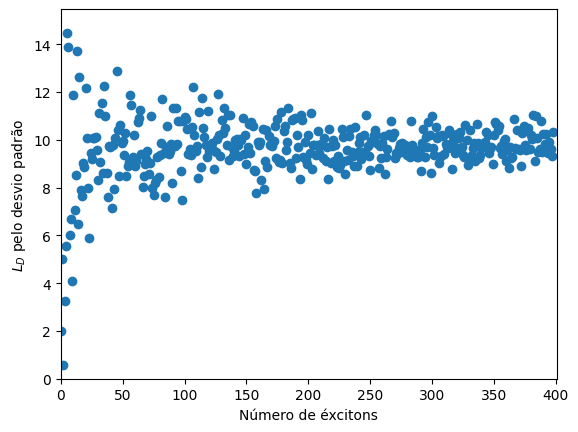

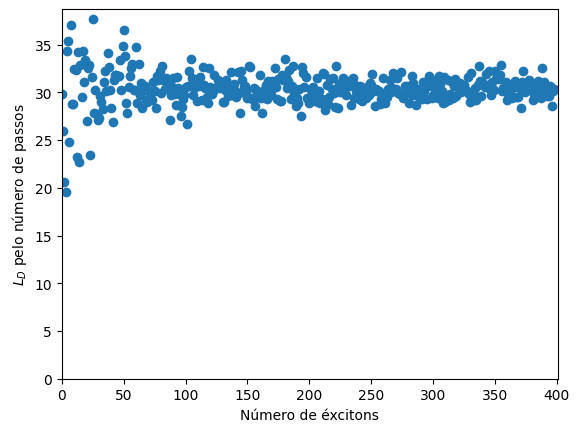

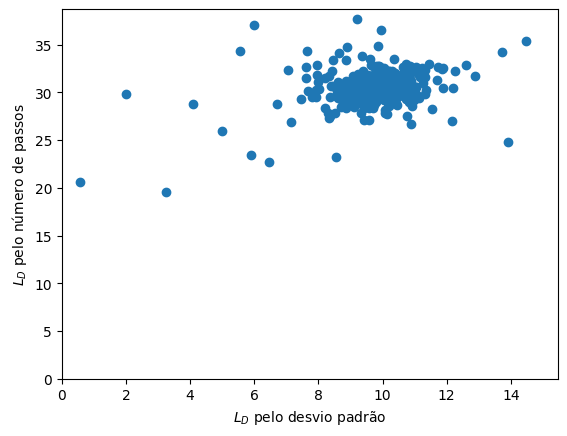

In [20]:
# Gráficos: Verificação do número de éxitons necessários

with open("dados_5.txt", "r") as arquivo:
    d = json.load(arquivo)

lista_L_D_steps = d["L_D_steps"]
lista_L_D_sig = d["L_D_sig"]
lista_n = d["n_exc"]

# Comprimento de difusão calculado pelo desvio padrão vs número de éxcitons

plt.figure()
plt.plot(lista_n, lista_L_D_sig, "o")
plt.ylabel(r"$L_D$ pelo desvio padrão")
plt.xlabel(r"Número de éxcitons")
plt.xlim(0,N+1)
plt.ylim(0,max(lista_L_D_sig)+1)
plt.show()

# Comprimento de difusão calculado pels passos vs número de éxcitons

plt.figure()
plt.plot(lista_n, lista_L_D_steps, "o")
plt.ylabel(r"$L_D$ pelo número de passos")
plt.xlabel(r"Número de éxcitons")
plt.xlim(0,N+1)
plt.ylim(0,max(lista_L_D_steps)+1)
plt.show()

# Comparação entre os comprimentos calculados 

plt.figure()
plt.plot(lista_L_D_sig, lista_L_D_steps, "o")
plt.ylabel(r"$L_D$ pelo número de passos")
plt.xlabel(r"$L_D$ pelo desvio padrão")
plt.xlim(0,max(lista_L_D_sig)+1)
plt.ylim(0,max(lista_L_D_steps)+1)
plt.show()



In [ ]:
# Comprimento de difusão calculado pelos passos vs analítico (variando R_0)

with open("dados_4.txt", "r") as arquivo:
    d = json.load(arquivo)     # Rede

from joblib import Parallel, delayed


n = 300  #número de éxcitons 
R_0 = np.arange(3,10,0.25)

resultados = Parallel(n_jobs=-1)(delayed(L_D_calc)(d,R_0[i],r,Tau,n) for i in range(len(R_0)))

L_D_sig = [resultados[i][0] for i in range(len(R_0))]
L_D_steps = [resultados[i][1] for i in range(len(R_0))]

print(resultados)
print(L_D_sig)

lista_L_D_an = []
for i in range(len(R_0)):
    lista_L_D_an.append(L_D_an(R_0[i],r))

d = {"Sig_R0": L_D_sig, "Steps_R0": L_D_steps, "An_R0": lista_L_D_an}

with open("dados_6.txt", "w") as arquivo:
    json.dump(d, arquivo)
arquivo.close()


[(np.float64(0.8698658900466593), 1.0939226054281292), (np.float64(1.5154757228892408), 2.004162335407655), (np.float64(2.157931107951935), 3.4703506066870724), (np.float64(2.6312227829154513), 5.247539105777742), (np.float64(3.954322529418493), 8.438601779915912), (np.float64(4.793050524804984), 11.751028323796461), (np.float64(5.846081308591822), 16.308586695357757), (np.float64(6.994283380018285), 22.597197466352622), (np.float64(7.7781745930520225), 29.51417738421091), (np.float64(8.048395285189878), 36.104985805287335), (np.float64(10.425129895273887), 42.58830042785616), (np.float64(11.246629124616259), 55.09718686103674), (np.float64(11.166169143145439), 67.30832043662953), (np.float64(14.477914214416385), 78.81084950690482), (np.float64(14.878171930717834), 91.28000876424147), (np.float64(15.911316727411343), 109.48215988613549), (np.float64(16.87512962913174), 127.57234548809288), (np.float64(16.773391626819745), 150.04976952109368), (np.float64(20.44170573443746), 163.4688859

In [ ]:
# Comprimento de difusão calculado pelos passos vs analítico (variando R_0)
# Valores altos de R_0

with open("dados_4.txt", "r") as arquivo:
    d = json.load(arquivo)     # Rede

from joblib import Parallel, delayed


n = 300  #número de éxcitons 
R_0 = np.arange(8,11,0.5)

resultados = Parallel(n_jobs=-1)(delayed(L_D_calc)(d,R_0[i],r,Tau,n) for i in range(len(R_0)))

L_D_sig = [resultados[i][0] for i in range(len(R_0))]
L_D_steps = [resultados[i][1] for i in range(len(R_0))]

print(resultados)
print(L_D_sig)

lista_L_D_an = []
for i in range(len(R_0)):
    lista_L_D_an.append(L_D_an(R_0[i],r))

d = {"Sig_R0": L_D_sig, "Steps_R0": L_D_steps, "An_R0": lista_L_D_an}

with open("dados_7.txt", "w") as arquivo:
    json.dump(d, arquivo)
arquivo.close()

[(np.float64(38.60466293079114), 558.088081459071), (np.float64(42.15641509110249), 622.2571788791727), (np.float64(47.60395641820821), 748.8631049798087), (np.float64(61.31082014348419), 882.1999376558581), (np.float64(65.18243628463115), 1015.5945500050697), (np.float64(72.44245992510193), 1144.1995120315921)]
[np.float64(38.60466293079114), np.float64(42.15641509110249), np.float64(47.60395641820821), np.float64(61.31082014348419), np.float64(65.18243628463115), np.float64(72.44245992510193)]


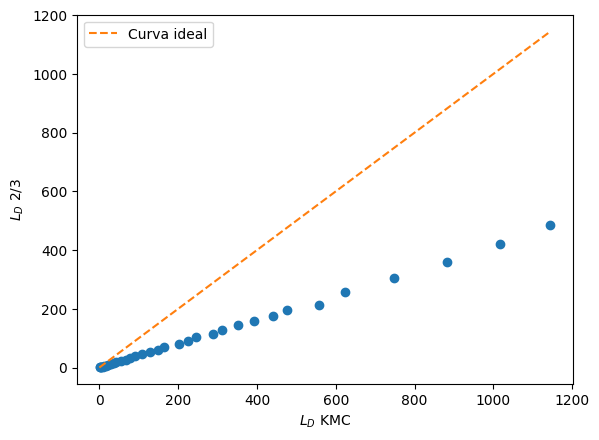

[0.4190262407031392, 0.8184106263733186, 1.4142135623730951, 2.2457187587683864, 3.3522099256251137, 4.772970773009196, 6.547285010986549, 8.7144363496231, 11.313708498984761, 14.38438516913745, 17.96575007014709, 22.09708691207961, 26.81767940500091, 32.16681125897692, 38.18376618407357, 44.90782789035675, 52.37828008789239, 60.63440648674646, 69.7154907969848, 79.66081672867335, 90.50966799187809, 102.30132829666482, 115.0750813530996, 128.8702108712483, 143.72600056117673, 159.68173413295096, 176.7766952966369, 195.05016776230028, 214.54143524000727, 257.33449007181537, 305.47012947258855, 359.262623122854, 419.02624070313914, 485.07525189397165]
[5.291502622129181, 8.74642784226795, 4.795831523312719, 7.968688725254614, 7.563068160475615, 8.916277250063503, 6.708203932499369, 7.842193570679061, 9.533566430716728, 8.514693182963201, 7.6098022910645255, 8.534244742994739, 8.686860103716329, 8.672617004934883, 8.962886439832502, 8.215838362577491, 7.211102550927978, 9.01233722306385, 

In [22]:
# Gráfico do comprimento analítico vs calculado pelo número de passos

with open("dados_6.txt", "r") as arquivo:
    d1 = json.load(arquivo)

with open("dados_7.txt", "r") as arquivo:
    d2 = json.load(arquivo)


L_D_steps = d1["Steps_R0"] + d2["Steps_R0"]
lista_L_D_an = d1["An_R0"] + d2["An_R0"]

plt.figure()
plt.plot(L_D_steps, lista_L_D_an, "o")
plt.xlabel(r"$L_D$ KMC")
plt.ylabel(r"$L_D$ 2/3")
L_D_max = max(L_D_steps + lista_L_D_an)
plt.plot([0, L_D_max], [0, L_D_max], '--', label = 'Curva ideal')
plt.legend()
plt.show()
print(lista_L_D_an)
print(lista_L_D_steps)

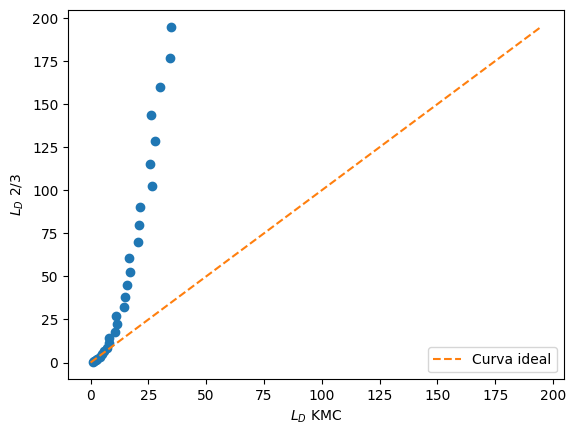

In [23]:
# Comprimento de difusão calculado pelo desvio padrão vs analítico (variando R_0)

with open("dados_6.txt", "r") as arquivo:
    d = json.load(arquivo)

L_D_sig = d["Sig_R0"]
lista_L_D_an = d["An_R0"]

plt.figure()
plt.plot(L_D_sig, np.array(lista_L_D_an), "o")
plt.xlabel(r"$L_D$ KMC")
plt.ylabel(r"$L_D$ 2/3")
L_D_max = max(L_D_sig + lista_L_D_an)
plt.plot([0, L_D_max], [0, L_D_max], '--', label = 'Curva ideal')
plt.legend()
plt.show()
